# Iris Flower Classification using K-Nearest Neighbors (KNN)


## Step 1: Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Dataset

In [23]:
# Load the Iris dataset from sklearn
iris = load_iris()

# Create a DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


## Step 3: Explore the Dataset

In [24]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [25]:
# Statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [26]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [27]:
# Class distribution
print("Class distribution:")
print(df['species_name'].value_counts())

Class distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


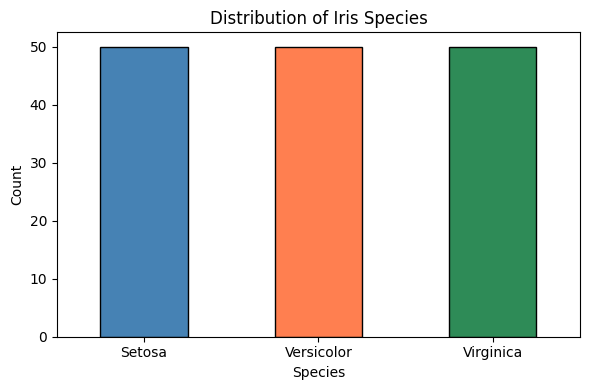

In [28]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
df['species_name'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

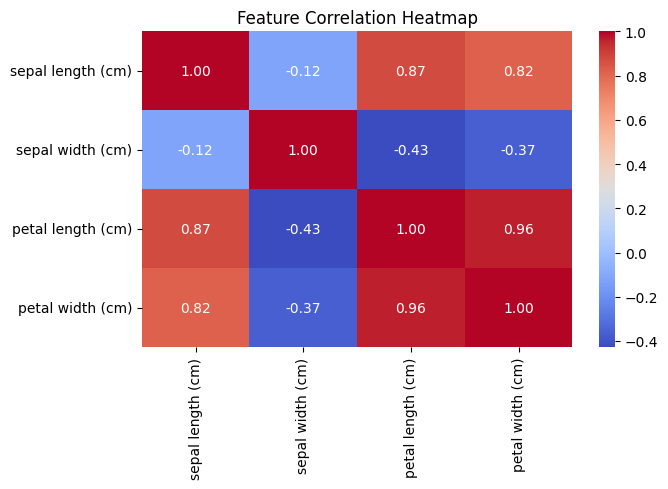

In [29]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [30]:
# Separate features (X) and target (y)
X = df[iris.feature_names].values
y = df['species'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## Step 5: Train-Test Split

In [31]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Step 6: Feature Scaling (StandardScaler)

In [32]:
# StandardScaler makes features have mean=0 and std=1
# This is important for KNN because it uses distance calculations
scaler = StandardScaler()

# Fit on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling (first sample):", X_train[0])
print("After scaling  (first sample):", X_train_scaled[0].round(3))

Before scaling (first sample): [4.4 2.9 1.4 0.2]
After scaling  (first sample): [-1.722 -0.332 -1.346 -1.323]


## Step 7: Find the Best K Value

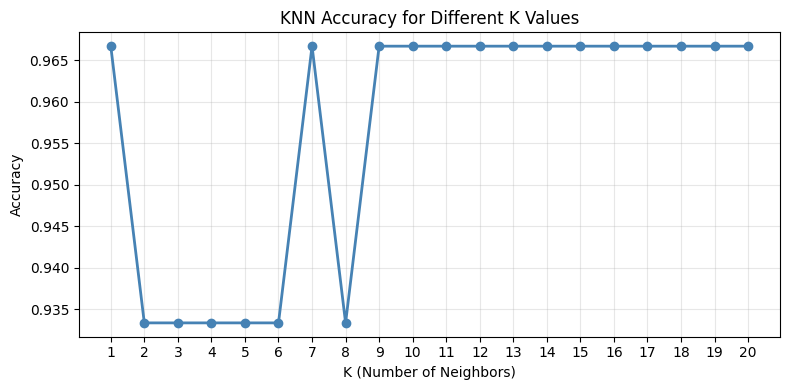

Best K = 1, Accuracy = 96.67%


In [33]:
# Test different K values from 1 to 20
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    score = knn_temp.score(X_test_scaled, y_test)
    k_scores.append(score)

# Plot accuracy vs K
plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, 'o-', color='steelblue', linewidth=2)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(k_scores)]
print(f"Best K = {best_k}, Accuracy = {max(k_scores)*100:.2f}%")

## Step 8: Train the KNN Model

In [34]:
# Create and train the KNN model with the best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

print(f"KNN model trained with K = {best_k}")

KNN model trained with K = 1


## Step 9: Make Predictions

In [35]:
# Predict on the test set
y_pred = knn.predict(X_test_scaled)

# Show actual vs predicted
comparison = pd.DataFrame({
    'Actual': [iris.target_names[i] for i in y_test],
    'Predicted': [iris.target_names[i] for i in y_pred]
})
comparison

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


## Step 10: Model Evaluation

In [36]:
# 1. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.67%


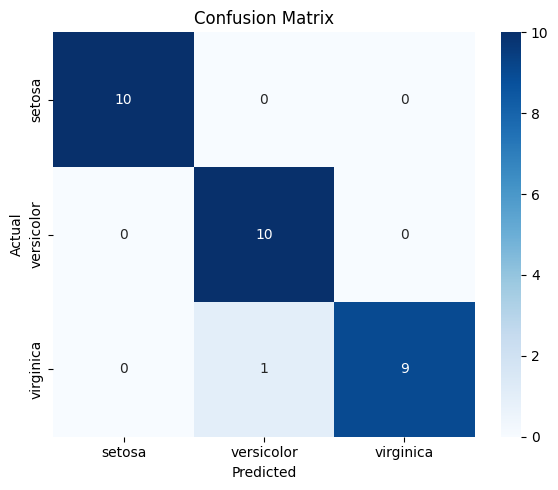

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [37]:
# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [38]:
# 3. F1 Score
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_per_class = f1_score(y_test, y_pred, average=None)

print(f"Weighted F1 Score: {f1_weighted:.4f}")
print("\nF1 Score per class:")
for name, score in zip(iris.target_names, f1_per_class):
    print(f"  {name}: {score:.4f}")

Weighted F1 Score: 0.9666

F1 Score per class:
  setosa: 1.0000
  versicolor: 0.9524
  virginica: 0.9474


In [39]:
# 4. Full Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

